# 🇬🇧 UK Spending Intelligence Platform
## Notebook 1 — Data Ingestion

**Goal:** Pull spending datasets from the UK Government's open data API (data.gov.uk / CKAN),
save raw data as Parquet files, and handle errors gracefully.

**What you'll learn:**
- How to call a real government REST API
- How to page through large result sets
- How to save data in Parquet format (efficient columnar storage)
- Basic error handling for production pipelines

---
**Architecture position:** `Source → [Ingestion] → Transform → Warehouse → Dashboard`

Ingestion:

*ingestion.py

In [ ]:
import pandas as pd

# -----------------------------
# LOAD & CLEAN DATA
# -----------------------------
url = "https://www.gov.uk/government/uploads/system/uploads/attachment_data/file/657995/CRA_2017_Database.xlsx"

df = pd.read_excel(url)
print(df.head())

xls = pd.ExcelFile(url)
print(xls.sheet_names)

df = pd.read_excel(url, sheet_name="CRA 2017 database")
print(df.shape)



                       Unnamed: 0  Unnamed: 1  \
0  Expenditure 2012-13 to 2016-17         NaN   
1                             NaN         NaN   
2                             NaN         NaN   
3                      Department         NaN   
4                             NaN         NaN   

                                          Unnamed: 2 Unnamed: 3  Unnamed: 4  \
0  Levels of expenditure shown are in £'000s. Exp...        NaN         NaN   
1  costs occur rather than when the payment is ma...        NaN         NaN   
2                                                NaN        NaN         NaN   
3  The part of the public sector responsible for ...        NaN         NaN   
4                                                NaN        NaN         NaN   

   Unnamed: 5 Unnamed: 6 Unnamed: 7  Unnamed: 8  Unnamed: 9  Unnamed: 10  \
0         NaN        NaN        NaN         NaN         NaN          NaN   
1         NaN        NaN        NaN         NaN         NaN          NaN   
2 

Transform

In [ ]:
df.columns = (
    df.columns
    .str.lower()               # "Department Name" → "department name"
    .str.strip()               # remove spaces at the start/end
)
rename_columns = {
    "department": "department",
    "cra_segment_code": "segment_code",
    "cra_segment_name": "segment_name",
    "cofog_level_0": "cofog_level_0",
    "hmt_function": "function",
    "cofog_level_1": "cofog_level_1",
    "hmt_subfunction": "subfunction",
    "id/nonid": "spend_type",
    "cap_or_cur": "capital_or_current",
    "cg,_lg,_pc,_boe": "govt_sector",
    "allocated_by_hmt_or_dept": "allocated_under",
    "nuts_region": "region",
    "country": "country",
    "year": "year",
    "spending_gbp_m": "spending",
    "201213": "2012-2013",
    "201314": "2013-2014",
    "201415": "2014-2015",
    "201516": "2015-2016",
    "201617": "2016-2017"
}

df = df.rename(columns=rename_columns)
df.drop_duplicates()
df.isnull().sum()
df.fillna(0, inplace=True)
df.to_csv("clean_data.csv")
print("Clean data saved to clean_data.csv in csv format")


Clean data saved to clean_data in csv format


LOAD

In [49]:
from sqlalchemy import create_engine, text
df = pd.read_csv("clean_data.csv")
DB_URL = (
    "postgresql+psycopg2://testdbms:Atomic90600665"
    "@database-1.cjewm0cgaphq.eu-north-1.rds.amazonaws.com:5432/postgres"
)
engine = create_engine(DB_URL)
df.to_sql(
        name=TABLE_NAME,
        con=engine,
        if_exists="replace",
        index=False
    )
print(" Upload complete!")
query = text(f"SELECT DISTINCT country FROM {TABLE_NAME} ORDER BY country;")
with engine.connect() as conn:
    countries = [row[0] for row in conn.execute(query)]
print(countries)
print("Test passed")

 Upload complete!
['ENGLAND', 'NON-REGIONAL', 'NORTHERN IRELAND', 'OUTSIDE UK', 'SCOTLAND', 'WALES']
Test passed


EDA

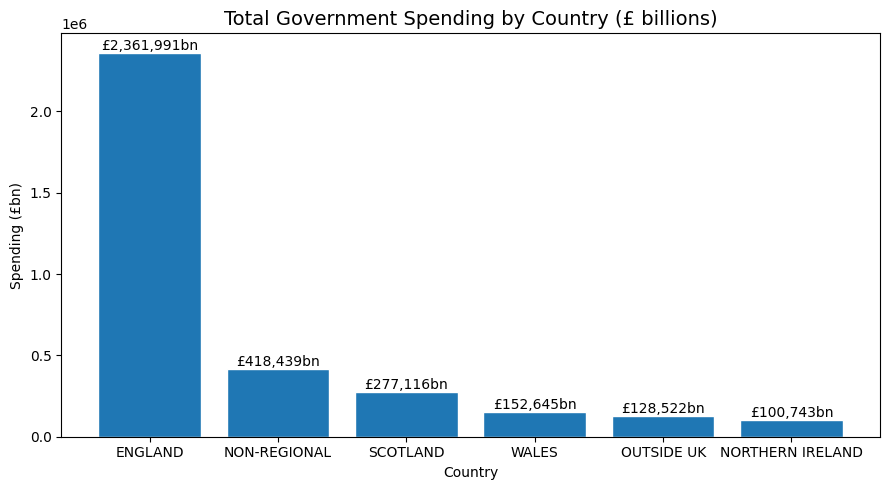

saved plot 1


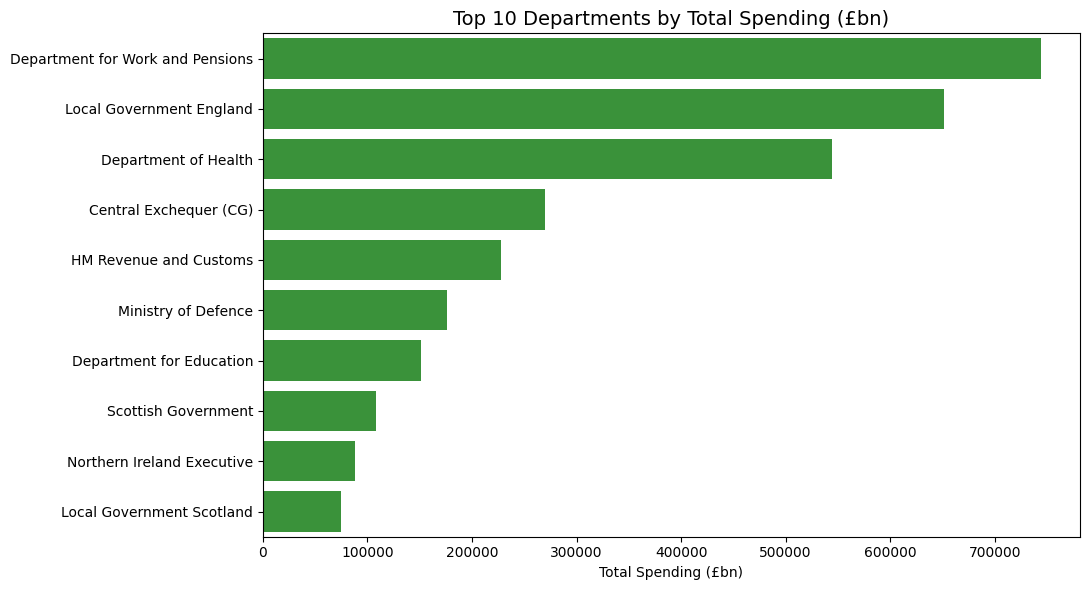

saved plot 2


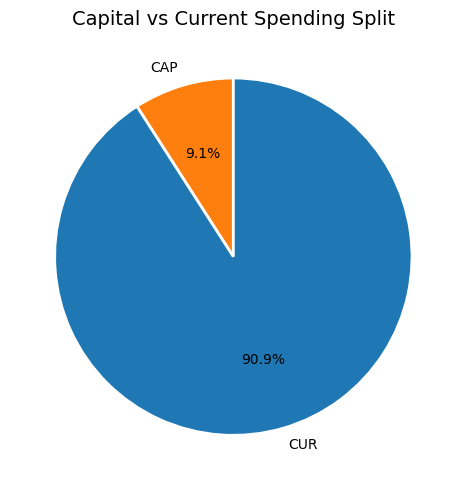

saved plot 3


KeyError: "None of [Index(['2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017'], dtype='object')] are in the [columns]"

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned data to ensure df is defined
df = pd.read_csv('clean_data.csv')

# Drop the 'Unnamed: 0' column if it exists (often created when reading CSVs saved with default index)
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Re-apply the column renaming to ensure consistent column names across notebook runs.
# The 'rename_columns' dictionary should be defined in a previous cell or be globally available.
# Assuming rename_columns is available from previous execution context.
rename_columns = {
    "department": "department",
    "cra_segment_code": "segment_code",
    "cra_segment_name": "segment_name",
    "cofog_level_0": "cofog_level_0",
    "hmt_function": "function",
    "cofog_level_1": "cofog_level_1",
    "hmt_subfunction": "subfunction",
    "id/nonid": "spend_type",
    "cap_or_cur": "capital_or_current",
    "cg,_lg,_pc,_boe": "govt_sector",
    "allocated_by_hmt_or_dept": "allocated_under",
    "nuts_region": "region",
    "country": "country",
    "year": "year",
    "spending_gbp_m": "spending",
    "201213": "2012-2013",
    "201314": "2013-2014",
    "201415": "2014-2015",
    "201516": "2015-2016",
    "201617": "2016-2017"
}
df = df.rename(columns=rename_columns)

# -----------------------------
# PLOT 1 - TOTAL SPENDING BY COUNTRY
# -----------------------------
spending_by_country = (
    df.groupby("country")["spending"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(9, 5))
bars = plt.bar(spending_by_country["country"], spending_by_country["spending"] / 1000,
               color="#1f77b4", edgecolor="white")

for bar, val in zip(bars, spending_by_country["spending"] / 1000):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"£{val:,.0f}bn", ha="center", va="bottom", fontsize=10)

plt.title("Total Government Spending by Country (£ billions)", fontsize=14)
plt.xlabel("Country")
plt.ylabel("Spending (£bn)")
plt.tight_layout()
plt.savefig("plot_01_spending_by_country.png", dpi=150)
plt.show()
print("saved plot 1")

# -----------------------------
# PLOT 2 - TOP 10 DEPARTMENTS BY SPENDING
# -----------------------------
top_depts = (
    df.groupby("department")["spending"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(11, 6))
sns.barplot(x=top_depts.values / 1000, y=top_depts.index, color="#2ca02c")

plt.title("Top 10 Departments by Total Spending (£bn)", fontsize=14)
plt.xlabel("Total Spending (£bn)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("plot_02_top_departments.png", dpi=150)
plt.show()
print("saved plot 2")

# -----------------------------
# PLOT 3 - CAPITAL vs CURRENT SPENDING
# -----------------------------
cap_cur = df.groupby("capital_or_current")["spending"].sum()

plt.figure(figsize=(7, 5))
wedges, texts, autotexts = plt.pie(
    cap_cur.values,
    labels=cap_cur.index,
    autopct="%1.1f%%",
    colors=["#ff7f0e", "#1f77b4"],
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2),
)
plt.title("Capital vs Current Spending Split", fontsize=14)
plt.tight_layout()
plt.savefig("plot_03_capital_vs_current.png", dpi=150)
plt.show()
print("saved plot 3")

# -----------------------------
# PLOT 4 - SPENDING TREND OVER YEARS
# -----------------------------
# the yearly columns give us the time series without needing to reshape
year_cols = ["2012-2013", "2013-2014", "2014-2015", "2015-2016", "2016-2017"]
yearly_totals = df[year_cols].sum() / 1000   # convert to £bn

plt.figure(figsize=(10, 5))
plt.plot(yearly_totals.index, yearly_totals.values, marker="o", linewidth=2, color="#d62728")

for x, y in zip(yearly_totals.index, yearly_totals.values):
    plt.text(x, y + 5, f"£{y:,.0f}bn", ha="center", fontsize=9)

plt.title("Total Government Spending by Year (£bn)", fontsize=14)
plt.xlabel("Financial Year")
plt.ylabel("Spending (£bn)")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("plot_04_spending_trend.png", dpi=150)
plt.show()
print("saved plot 4")

# -----------------------------
# PLOT 5 - SPENDING BY FUNCTION (cofog)
# -----------------------------
by_function = (
    df.groupby("function")["spending"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
)

plt.figure(figsize=(11, 6))
sns.barplot(x=by_function.values / 1000, y=by_function.index, color="#9467bd")

plt.title("Total Spending by Government Function - Top 8 (£bn)", fontsize=14)
plt.xlabel("Total Spending (£bn)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("plot_05_by_function.png", dpi=150)
plt.show()
print("saved plot 5")

# -----------------------------
# PLOT 6 - SPENDING BY REGION
# -----------------------------
by_region = (
    df.groupby("region")["spending"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 6))
sns.barplot(x=by_region.values / 1000, y=by_region.index, color="#8c564b")

plt.title("Total Spending by Region (£bn)", fontsize=14)
plt.xlabel("Total Spending (£bn)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("plot_06_by_region.png", dpi=150)
plt.show()
print("saved plot 6")

print("\nEDA complete - all 6 plots saved")
print(TABLE_NAME)